# Interventional influence map — the controlled experiment

Every other analysis in this project infers dependence from observed
co-movement, which is why seasonality, drift, regime mixture and
self-predictability kept confounding it. Here **we set the cause**: a flat
network, one node perturbed at a time, response measured everywhere. The
response *is* the effect — no inference, no null hypothesis, no confound.

**What this produces.** `d(response_j)/d(demand_i)` for every perturbed node
*i* and target *j*. EPANET's simulation is quasi-static, so a flat network
sits at one steady state and a perturbation moves it to another. There is no
transport lag to find: this is a **Jacobian, not a dynamic response**, and
`duration=0` is the correct simulation — one solve, tanks pinned at initial
level. Running longer would let tanks cycle and reintroduce the drift this
design removes.

**Two results that decide how everything downstream must be read**, both
verified on hand-built networks before running here:

| quantity | property | usable for |
|---|---|---|
| pressure `dP_j/dD_i` | **symmetric** (Maxwell–Betti reciprocity) | coupling **strength** only |
| flow `dQ_p/dD_i` | **asymmetric** — a routing matrix | **direction** (who supplies whom) |

Pressure influence can never yield direction; that is a theorem about
resistive networks, not a property of this dataset. Direction comes from
flows, because a downstream district's demand loads the upstream district's
mains while the reverse never happens.

**Scope.** This is a diagnostic world, not an FL dataset — flat consumption
removes the regime signal the thesis is about. Use it to validate the
observational statistics and to place sensors, then go back to the drift
worlds to learn.

In [1]:
import sys, pathlib, copy
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import wntr, yaml

HERE = pathlib.Path.cwd().resolve()
PROJ = next((p for p in [HERE, *HERE.parents] if (p / "pyproject.toml").exists()), HERE)
for p in (PROJ / "src", PROJ / "notebooks", PROJ, HERE):
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))
import sensitivity_probe as S

INP       = PROJ / "data/01_raw/Graeme.inp"
DISTRICTS = yaml.safe_load((PROJ / "data/01_raw/districts_graeme.yml").read_text())
BASE      = yaml.safe_load((PROJ / "conf/base/parameters.yml").read_text())
ANCHOR    = BASE["hydraulics"]["anchor_scale"]
DEMAND_MULT = BASE["hydraulics"]["demand_multiplier"]   # Graeme.inp ships 0.2!

wn_raw = wntr.network.WaterNetworkModel(str(INP))
print(f"{len(wn_raw.junction_name_list)} junctions | {len(wn_raw.pipe_name_list)} pipes | "
      f"{len(wn_raw.tank_name_list)} tanks | {len(wn_raw.reservoir_name_list)} reservoirs")
pd.set_option("display.width", 160)

113 junctions | 164 pipes | 0 tanks | 1 reservoirs


## 1. Flat baseline

Patterns are stripped rather than flattened, so nothing downstream can
reintroduce a diurnal shape. `anchor_scale` matches `conf/base` so the
operating point is the one the rest of the project runs at — the Jacobian is
only valid near the baseline it is measured at.

In [2]:
print("inp global demand multiplier:", wn_raw.options.hydraulic.demand_multiplier,
      "-> pinning to", DEMAND_MULT)
flat = S.flat_baseline(wn_raw, anchor_scale=ANCHOR, demand_multiplier=DEMAND_MULT)
d0 = S.node_demands(flat)
print(f"demand: total {d0.sum():.4f} m3/s | mean {d0.mean():.6f} | "
      f"zero-demand junctions {(d0 == 0).sum()}")
print("source links:", S.source_links(flat)[:6], "...")

inp global demand multiplier: 0.2 -> pinning to 1.0
demand: total 0.2779 m3/s | mean 0.002459 | zero-demand junctions 1
source links: [('184', -1.0)] ...


### SC-1 — is the flat world actually flat?

Tanks integrate net inflow, so a constant-demand network can still drift as
they fill and drain. The `duration=0` Jacobian is valid regardless (tanks are
pinned there), but if this reports `flat=False`, no *time-series* reading of
this world is trustworthy.

In [3]:
display(S.check_baseline_flat(flat, n_steps=48))

,n_tanks,n_steps,flow_cv,pressure_range_med,flat
0,0,49,3.661953e-07,0.0,True


## 2. The sweep

Perturbations are **additive**, not multiplicative: it keeps the magnitude
identical across nodes (a true partial derivative, comparable entries) and it
still works for the many junctions whose base demand is zero, which a
multiplier would leave untouched. Three levels, so nonlinearity is measured
rather than assumed away.

In [4]:
mean_d = float(d0[d0 > 0].mean())
DELTAS = [0.5 * mean_d, 1.0 * mean_d, 2.0 * mean_d]     # low / medium / high
print("deltas (m3/s):", [round(x, 6) for x in DELTAS])

sweep, diag = S.perturbation_sweep(flat, DELTAS, verbose=True)
print(f"\nsolves {len(diag)} | infeasible {int((~diag.feasible).sum())} | "
      f"rows {len(sweep)}")
display(diag.groupby("kind")["feasible"].agg(["count", "mean"]))

deltas (m3/s): [0.00124, 0.002481, 0.004962]
  20/113 nodes
  40/113 nodes
  60/113 nodes
  80/113 nodes
  100/113 nodes

solves 340 | infeasible 0 | rows 94242


,count,mean
kind,,
baseline,1,1.0
perturbed,339,1.0


### SC-2 — physics checks

- **Mass balance**: every added m³/s must reappear at the sources. A hard
  constraint that catches any sign or bookkeeping error.
- **Diagonal dominance**: perturbing node *i* must move *i*'s own pressure
  most. Ties are expected and physical (a node just below the source raises
  head loss only in the supply main, so everything downstream drops
  equally), so the test is weak dominance within 1%.
- **Reciprocity**: `dP_j/dD_i == dP_i/dD_j`. If this fails the solver is
  wrong; if it passes, pressure cannot give direction.

In [5]:
mb = S.check_mass_balance(sweep, flat)
print(f"mass balance  max rel error {mb.rel_error.max():.2e}  "
      f"(EPANET reports to finite precision; <1e-4 is exact)")
if mb.rel_error.max() > 1e-4:
    print("  ^ a CONSTANT relative error means a global scaling is being "
          "applied that the sweep does not know about -- check "
          "options.hydraulic.demand_multiplier first.")

dd = S.check_diagonal_dominance(sweep)
print(f"diagonal dominance  self_is_max {dd.self_is_max.mean():.3f}  "
      f"min self/max {dd.self_frac_of_max.min():.3f}")

display(S.check_reciprocity(sweep, flat, delta=DELTAS[1]))

mass balance  max rel error 4.85e-06  (EPANET reports to finite precision; <1e-4 is exact)
diagonal dominance  self_is_max 1.000  min self/max 1.000


,n_nodes,max_abs_asymmetry,max_abs_sensitivity,relative_asymmetry,symmetric
0,113,0.019989,26.953955,0.000742,True


### SC-3 — how far does the linear map extrapolate?

Head loss goes as ~Q^1.85, so responses do not superpose. `ratio_median`
near 1.0 means sensitivity is stable between the smallest and largest
perturbation; departures are the honest bound on extrapolation.

In [6]:
for q in ("flowrate", "pressure"):
    display(S.check_linearity(sweep, q))

,quantity,delta_lo,delta_hi,n_pairs,ratio_median,ratio_p05,ratio_p95,max_abs_dev_from_1
0,flowrate,0.00124,0.004962,14822,1.005332,0.975385,1.053996,137.883331


,quantity,delta_lo,delta_hi,n_pairs,ratio_median,ratio_p05,ratio_p95,max_abs_dev_from_1
0,pressure,0.00124,0.004962,12769,1.005862,1.005563,1.007056,0.013438


## 3. Coupling strength (pressure — symmetric)

In [7]:
M = S.district_influence(sweep, DISTRICTS, flat, "pressure", delta=DELTAS[1])
display(M.round(3))
display(S.influence_asymmetry(M).round(4))
print("asymmetry_ratio ~1.0 everywhere is RECIPROCITY, not a null result.")

display(S.cross_district_leakage(sweep, DISTRICTS, "pressure", delta=DELTAS[1]))

d_tgt,District_A,District_B,District_C,District_D,District_E
d_src,,,,,
District_A,20.104,19.629000,19.629,19.629000,19.629000
District_B,19.628,23.535999,21.737,21.520000,21.525999
District_C,19.628,21.735001,23.545,23.211000,23.222000
District_D,19.628,21.518000,23.205,25.322001,25.572001
District_E,19.628,21.524000,23.216,25.568001,26.250000


,district_a,district_b,infl_a_to_b,infl_b_to_a,dominant_direction,asymmetry_ratio,coupling_strength
0,District_A,District_B,19.6290,19.6285,District_A->District_B,1.0000,19.6287
1,District_A,District_C,19.6287,19.6285,District_A->District_C,1.0000,19.6286
2,District_A,District_D,19.6290,19.6285,District_A->District_D,1.0000,19.6287
3,District_A,District_E,19.6288,19.6285,District_A->District_E,1.0000,19.6286
4,District_B,District_C,21.7366,21.7347,District_B->District_C,1.0001,21.7356
5,District_B,District_D,21.5200,21.5181,District_B->District_D,1.0001,21.5190
6,District_B,District_E,21.5265,21.5244,District_B->District_E,1.0001,21.5254
7,District_C,District_D,23.2105,23.2052,District_C->District_D,1.0002,23.2079
8,District_C,District_E,23.2215,23.2161,District_C->District_E,1.0002,23.2188
9,District_D,District_E,25.5719,25.5683,District_D->District_E,1.0001,25.5701


asymmetry_ratio ~1.0 everywhere is RECIPROCITY, not a null result.


,within_district,between_district,ratio
0,24.605474,21.998148,1.118525


## 4. Direction (flow — the supply map)

`D[A, B]` = the fraction of district B's demand increment that transits
district A's internal pipes. Read as **"B is supplied through A"**, so A is
upstream of B. 1.0 = all of B's water crosses A; 0.0 = none does.

Pairs whose two directions agree within 2% are reported as
`mutual/parallel` rather than forced into a direction — in a looped network
that is a real configuration, not a failure to decide.

In [8]:
D = S.supply_dependency(sweep, DISTRICTS, flat, delta=DELTAS[1])
display(D.round(3))

dp = S.directed_pairs(D)
display(dp.round(4))

demand_of,District_A,District_B,District_C,District_D,District_E
transits_through,,,,,
District_A,1.0,1.000,1.000,1.000,1.000
District_B,0.0,0.846,0.544,0.470,0.460
District_C,0.0,0.290,0.777,0.700,0.576
District_D,0.0,0.058,0.101,1.000,0.576
District_E,0.0,0.006,0.010,0.682,1.000


,district_a,district_b,b_transits_a,a_transits_b,verdict,asymmetry,coupled
0,District_A,District_B,1.0000,0.0000,District_A upstream of District_B,1.0000,True
1,District_A,District_C,1.0000,0.0000,District_A upstream of District_C,1.0000,True
2,District_A,District_D,1.0000,0.0000,District_A upstream of District_D,1.0000,True
3,District_A,District_E,1.0000,0.0000,District_A upstream of District_E,1.0000,True
4,District_B,District_C,0.5442,0.2898,District_B upstream of District_C,0.2544,True
5,District_B,District_D,0.4695,0.0582,District_B upstream of District_D,0.4113,True
6,District_B,District_E,0.4596,0.0058,District_B upstream of District_E,0.4538,True
7,District_C,District_D,0.6998,0.1007,District_C upstream of District_D,0.5991,True
8,District_C,District_E,0.5757,0.0100,District_C upstream of District_E,0.5657,True
9,District_D,District_E,0.5757,0.6819,District_E upstream of District_D,0.1062,True


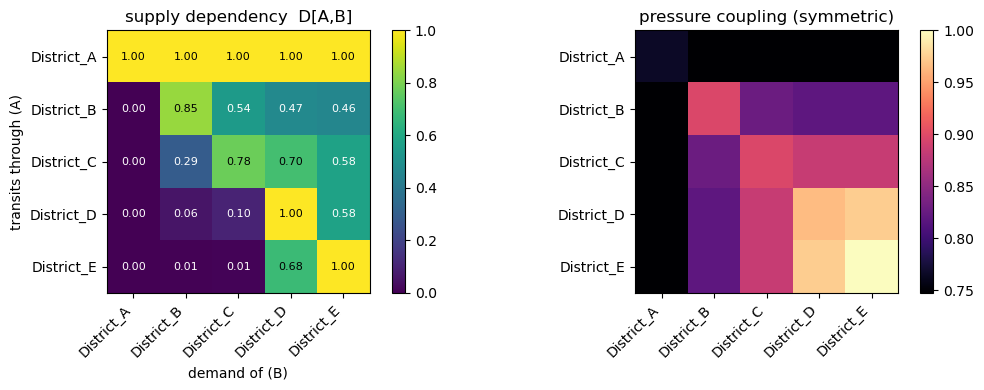

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
im = ax[0].imshow(D.to_numpy(), cmap="viridis", vmin=0, vmax=1)
ax[0].set_xticks(range(len(D.columns))); ax[0].set_xticklabels(D.columns, rotation=45, ha="right")
ax[0].set_yticks(range(len(D.index)));   ax[0].set_yticklabels(D.index)
ax[0].set_xlabel("demand of (B)"); ax[0].set_ylabel("transits through (A)")
ax[0].set_title("supply dependency  D[A,B]")
for i in range(len(D.index)):
    for j in range(len(D.columns)):
        ax[0].text(j, i, f"{D.iloc[i,j]:.2f}", ha="center", va="center",
                   color="w" if D.iloc[i,j] < .6 else "k", fontsize=8)
fig.colorbar(im, ax=ax[0], fraction=.046)

Mn = M.to_numpy() / np.nanmax(M.to_numpy())
im2 = ax[1].imshow(Mn, cmap="magma")
ax[1].set_xticks(range(len(M.columns))); ax[1].set_xticklabels(M.columns, rotation=45, ha="right")
ax[1].set_yticks(range(len(M.index)));   ax[1].set_yticklabels(M.index)
ax[1].set_title("pressure coupling (symmetric)")
fig.colorbar(im2, ax=ax[1], fraction=.046)
fig.tight_layout(); plt.show()

## 5. Node-level map

The full `dQ/dD` matrix is the routing structure of the network: which pipes
carry which node's water, and in what fraction when parallel paths exist.

flow sensitivity matrix: (113, 164)
fraction of exactly-zero entries: 0.2


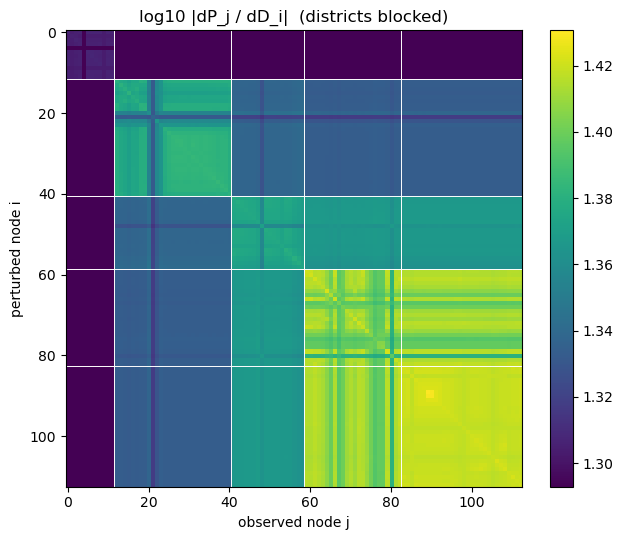

In [10]:
Qm = S.influence_matrix(sweep, "flowrate", delta=DELTAS[1])
print("flow sensitivity matrix:", Qm.shape)
print("fraction of exactly-zero entries:", float((Qm.abs() < 1e-9).mean().mean().round(3)))

n2d = {n: d for d, nodes in DISTRICTS["districts"].items() for n in nodes}
Pm = S.influence_matrix(sweep, "pressure", delta=DELTAS[1])
order = sorted([n for n in Pm.index if n in Pm.columns], key=lambda n: (n2d.get(n, ""), n))
Pm = Pm.loc[order, order]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(np.log10(Pm.abs() + 1e-6), cmap="viridis")
bounds, prev = [], None
for k, n in enumerate(order):
    if n2d.get(n) != prev:
        bounds.append(k); prev = n2d.get(n)
for b in bounds[1:]:
    ax.axhline(b - .5, c="w", lw=.7); ax.axvline(b - .5, c="w", lw=.7)
ax.set_title("log10 |dP_j / dD_i|  (districts blocked)")
ax.set_xlabel("observed node j"); ax.set_ylabel("perturbed node i")
fig.colorbar(im, fraction=.046); fig.tight_layout(); plt.show()

## 6. Ground truth for the observational work

This map is what the rest of the project was trying to estimate, so it can
now be used to score those methods rather than scoring them against
adjacency — a coarse binary proxy — as before.

In [11]:
gtb = None
gt_path = PROJ / "data/03_primary/gt_boundaries.csv"
if gt_path.exists():
    gtb = pd.read_csv(gt_path, dtype={"pipe": str})
    ds = sorted(DISTRICTS["districts"])
    adj = set()
    for _, r in gtb.iterrows():
        if not r.get("closed", False):
            adj.add((min(r.district_a, r.district_b), max(r.district_a, r.district_b)))
    rows = []
    for i, a in enumerate(ds):
        for b in ds[i+1:]:
            rows.append(dict(district_a=a, district_b=b,
                             adjacent=(a, b) in adj,
                             pressure_coupling=float(M.loc[a, b]),
                             supply_max=float(max(D.loc[a, b], D.loc[b, a]))))
    cmp = pd.DataFrame(rows)
    display(cmp.round(4))
    print("\nAdjacency is a BINARY proxy; these columns are the graded truth. "
          "Pairs that are non-adjacent yet strongly coupled are exactly what "
          "the AUROC label could not represent.")
else:
    print("gt_boundaries.csv not found -- run the pipeline once, or skip.")

,district_a,district_b,adjacent,pressure_coupling,supply_max
0,District_A,District_B,True,19.6290,1.0000
1,District_A,District_C,True,19.6287,1.0000
2,District_A,District_D,False,19.6290,1.0000
3,District_A,District_E,False,19.6288,1.0000
4,District_B,District_C,True,21.7366,0.5442
5,District_B,District_D,False,21.5200,0.4695
6,District_B,District_E,False,21.5265,0.4596
7,District_C,District_D,True,23.2105,0.6998
8,District_C,District_E,False,23.2215,0.5757
9,District_D,District_E,True,25.5719,0.6819



Adjacency is a BINARY proxy; these columns are the graded truth. Pairs that are non-adjacent yet strongly coupled are exactly what the AUROC label could not represent.


## 7. Interactive influence explorer

Each node is perturbed **individually**, so "what does district A affect" has
no single answer — it depends on how you collapse ~23 separate experiments.
The aggregator dropdown changes the question:

| aggregator | question |
|---|---|
| `max` | can **any** single node here move that target? (worst case) |
| `mean_all` | district-average influence — but unaffected targets count as 0, so it conflates *weakly* coupled with *rarely* coupled |
| `mean_changed` | when it does couple, by how much? **Read with `frac_changed`, never alone** |
| `frac_changed` / `n_changed` | breadth instead of depth |
| `sum` | total if every node were perturbed — extensive, so **not comparable across districts of different size** |

The perturbed district is outlined in cyan rather than shaded, and
"hide own district" is on by default: self-influence is always the largest
and would otherwise flatten the colour scale and hide the cross-district
structure that is the actual point.

In [12]:
S.influence_explorer(sweep, flat, DISTRICTS)

### Static panel — all districts, one aggregator

For the write-up, where a widget can't go.

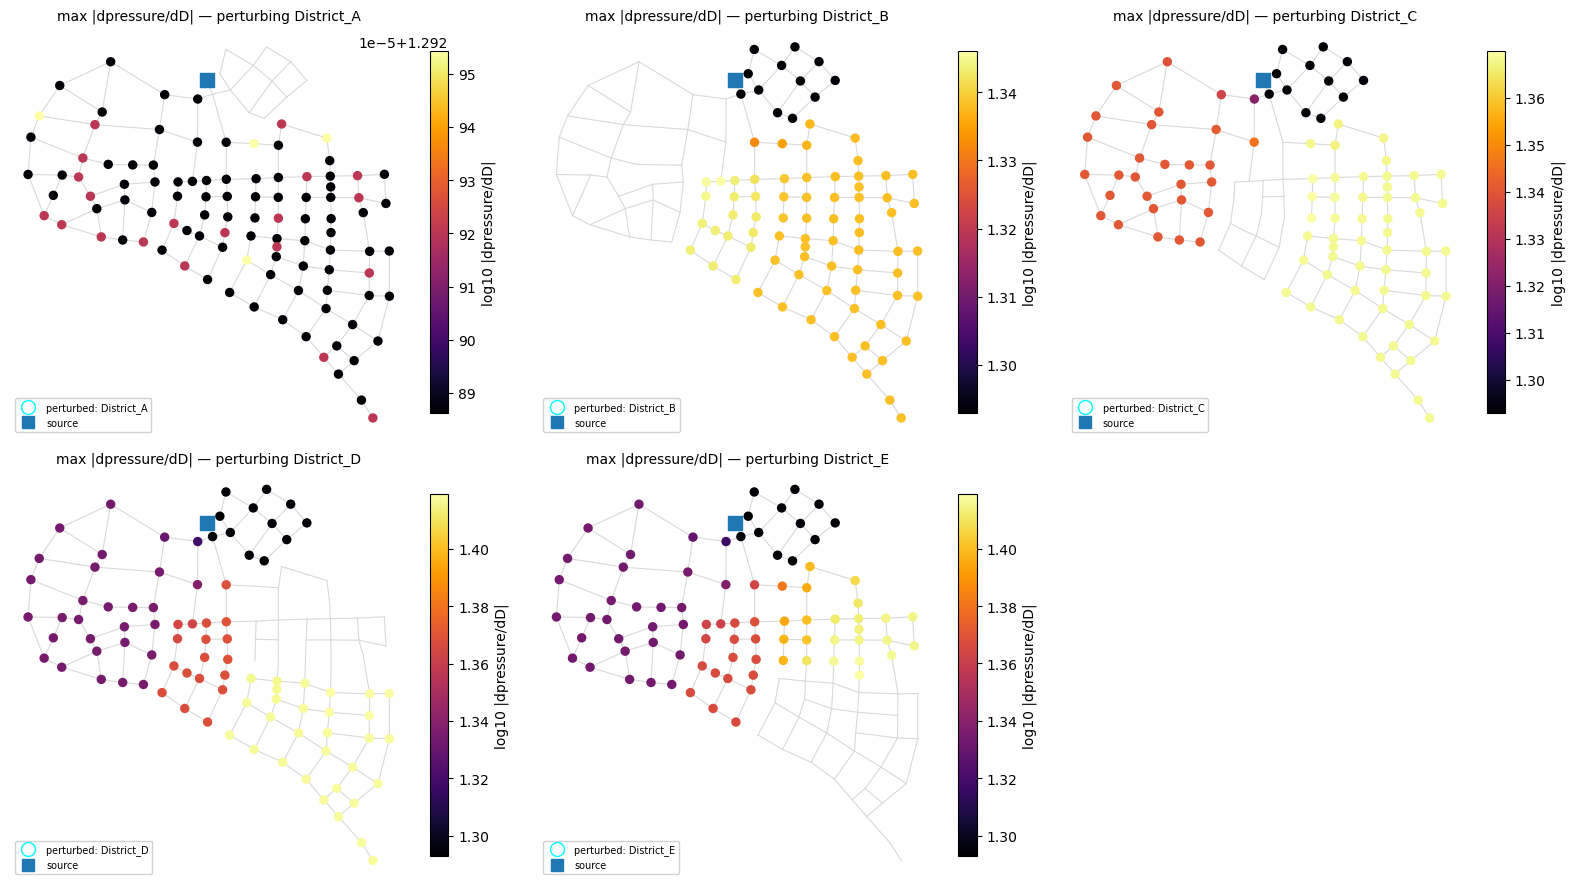

In [13]:
HOW, LOG = "max", True
ds = sorted(DISTRICTS["districts"])
n2d = {n: d for d, nn in DISTRICTS["districts"].items() for n in nn}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, src in zip(axes.ravel(), ds):
    vals = S.aggregate_response(sweep, DISTRICTS, src, quantity="pressure",
                                delta=DELTAS[1], how=HOW)
    vals = vals[[n2d.get(i) != src for i in vals.index]]      # hide own
    S.plot_network_influence(flat, DISTRICTS, vals, source=src,
                             quantity="pressure", how=HOW, log=LOG, ax=ax)
for ax in axes.ravel()[len(ds):]:
    ax.axis("off")
fig.tight_layout(); plt.show()

### Breadth vs depth

`frac_changed` and `mean_changed` answer different questions and can
disagree sharply: a district may touch every node weakly (high breadth, low
depth) or a handful strongly. Plotting them together is the honest summary.

aggregator,frac_changed,max,mean_all,mean_changed
source,,,,
District_A,0.9902,19.4364,19.4364,19.4364
District_B,0.9882,21.2704,21.0479,21.0479
District_C,0.9896,22.1966,22.0786,22.0786
District_D,0.9889,22.9498,22.7158,22.7158
District_E,0.9881,22.5254,22.5152,22.5152


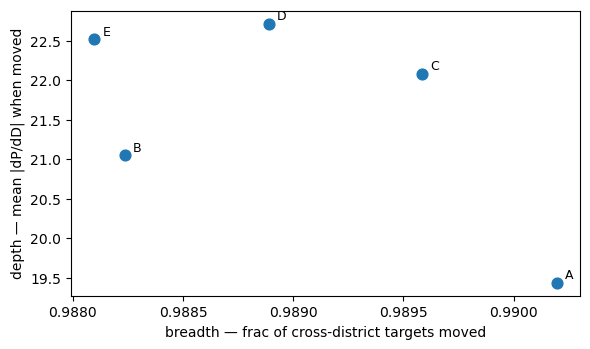

In [14]:
rows = []
for src in ds:
    for how in ("max", "mean_all", "mean_changed", "frac_changed"):
        v = S.aggregate_response(sweep, DISTRICTS, src, quantity="pressure",
                                 delta=DELTAS[1], how=how, threshold=1e-3)
        v = v[[n2d.get(i) != src for i in v.index]]
        rows.append(dict(source=src, aggregator=how, mean=float(v.mean()),
                         max=float(v.max())))
agg = pd.DataFrame(rows)
display(agg.pivot(index="source", columns="aggregator", values="mean").round(4))

fig, ax = plt.subplots(figsize=(6, 3.6))
b = agg[agg.aggregator == "frac_changed"].set_index("source")["mean"]
d = agg[agg.aggregator == "mean_changed"].set_index("source")["mean"]
ax.scatter(b, d, s=60)
for k in b.index:
    ax.annotate(k.replace("District_", ""), (b[k], d[k]),
                textcoords="offset points", xytext=(6, 3), fontsize=9)
ax.set_xlabel("breadth — frac of cross-district targets moved")
ax.set_ylabel("depth — mean |dP/dD| when moved")
fig.tight_layout(); plt.show()

## 8. What to do with this

- **Score the observational statistics properly.** Replace the binary
  adjacency label with `pressure_coupling` (strength) and `D` (direction).
  Spearman of `partial_rv` against `pressure_coupling` is the honest version
  of the AUROC we were computing.
- **Settle the direction question.** `directed_pairs` is the physical answer
  Granger could not produce. Compare it with the Granger verdicts from the
  observational notebook: agreement above chance would be a real finding,
  and the earlier evidence says it will not be.
- **Place sensors against measured influence** instead of topology proxies.
  The candidate that observes the most influence mass, with least redundancy,
  is now computable directly rather than approximated by `carry` and
  `d_boundary`.
- **Controls worth adding**: rerun on the `isolated` variant — cross-district
  influence must collapse to ~0, which is a strong negative control on the
  whole apparatus.

**Limits to state plainly**: one operating point, one network, static; valid
near this baseline only, with the departure bounded by SC-3. Nonlinearity
means the map should be re-measured if `anchor_scale` or the consumption
level changes materially.

## 9. Attributing observed similarity to the network

`reduction_pct` is the answer to "how much of this similarity is plumbing".
Both sides must be measured on the same objects: the observed statistic on
flow sensors is compared against the Jacobian restricted to those same
pipes, weighted by real per-node demand variability.

Use `pearson` as `obs_col`. `rho_hydraulic` is a correlation, so the ratio
is only apples-to-apples against another correlation -- `partial_rv` is an
RV coefficient on matrices and is not comparable this way.


In [15]:
# ---- observed similarity, from the SAME placement/quantity as the probe ----
import placement_poc as P

WORLD = P.discover_worlds(PROJ).query("usable and variant == 'baseline'").iloc[0]
art   = P.load_world(WORLD["dir"])

cands  = P.candidate_table(art["wn"], art["districts"])
feats, dist = P.topology_features(art["wn"], art["districts"], cands)
stats  = P.residual_stats(art["pressures"], art["flows"], cands, art["steps_day"])
pls    = P.strategies(cands, feats, stats, dist, art["params"], seed=0)

PLACEMENT, KIND, METHOD = "variance", "flow", "pearson"
placement = pls[PLACEMENT]

ss = P.build_series(art["pressures"], art["flows"], placement)
ss = ss[ss["kind"] == KIND]
mats, sigs = P.district_data(ss, art["steps_day"])
scores = P.pair_scores(mats, sigs, n_sur=99, seed=0)

observed = (scores[(scores.kind == KIND) & (scores.method == METHOD)]
            [["district_a", "district_b", "statistic"]])

# sensor names must match the probe's target namespace: LINK names for flow
sensors = {d: list(cfg[KIND]) for d, cfg in placement.items()}

# real per-node demand variability, not the uniform default
dem_path = PROJ / "data/02_intermediate/demand.parquet"
demand_std = None
if dem_path.exists():
    dem = pd.read_parquet(dem_path)
    demand_std = dem[[c for c in dem.columns if c != "month"]].std()

att = S.similarity_attribution(
    sweep, DISTRICTS, observed, sensors=sensors,
    quantity="flowrate" if KIND == "flow" else "pressure",
    delta=DELTAS[1], demand_std=demand_std, obs_col="statistic")

display(att.round(4).sort_values("reduction_pct", ascending=False))
print(f"\nmedian share of observed {METHOD} explained by hydraulics alone: "
      f"{att.reduction_pct.median():.1f}%")


,district_a,district_b,rho_observed,rho_hydraulic,excess,attributable_frac,reduction_pct
9,District_D,District_E,0.7008,0.7950,-0.0942,1.1344,113.4357
8,District_C,District_E,0.6344,0.6341,0.0004,0.9994,99.9385
4,District_B,District_C,0.9623,0.9461,0.0162,0.9832,98.3159
7,District_C,District_D,0.9002,0.8159,0.0843,0.9064,90.6362
0,District_A,District_B,0.8289,0.7499,0.0790,0.9047,90.4675
1,District_A,District_C,0.8206,0.7238,0.0968,0.8820,88.2025
6,District_B,District_E,0.6329,0.5361,0.0968,0.8470,84.7041
5,District_B,District_D,0.8635,0.6892,0.1743,0.7982,79.8161
3,District_A,District_E,0.5181,0.3569,0.1611,0.6890,68.8970
2,District_A,District_D,0.6815,0.4589,0.2227,0.6733,67.3281



median share of observed pearson explained by hydraulics alone: 89.3%


## 10. Two diagnostics on the attribution

**(1)** `demand_std` fails silently to uniform weights if `demand.parquet` is
absent -- and weighting moves `rho_hydraulic` materially, so which case you
are in has to be checked rather than assumed.

**(2)** `rho_hydraulic` comes from the probe and is FIXED. Only the observed
side is reprocessed here -- raw, deseasonalized, month-aware deseasonalized.
Deseasonalization removes the demand-side common mode, which is roughly the
assumption `rho_hydraulic` encodes, so residual correlations *should* look
almost purely hydraulic. If `raw` drives `rho_observed` toward 1 while
`reduction_pct` collapses, the regime signal lives in the profile that
deseasonalization discards.


In [16]:
# =====================================================================
# 1. Did demand_std actually load, and does it matter?
# =====================================================================
dem_path = PROJ / "data/02_intermediate/demand.parquet"
print("demand.parquet exists:", dem_path.exists())

demand_std = None
if dem_path.exists():
    dem  = pd.read_parquet(dem_path)
    cols = [c for c in dem.columns if c != "month"]
    demand_std = dem[cols].std()
    miss = [n for n in flat.junction_name_list if n not in demand_std.index]
    print(f"loaded std for {len(demand_std)} nodes | "
          f"min {demand_std.min():.3e}  max {demand_std.max():.3e}  "
          f"CV {demand_std.std()/demand_std.mean():.2f}")
    print(f"junctions in network but MISSING from demand.parquet: {len(miss)}"
          + (f"  -> {miss[:5]}" if miss else ""))
    if demand_std.max() == 0:
        print("  !! all-zero std -- weighting would be degenerate")
else:
    print("  !! FELL BACK TO UNIFORM WEIGHTS — rho_hydraulic below is unweighted")

# how much does the weighting actually change the answer?
QTY = "flowrate" if KIND == "flow" else "pressure"
cmp_w = None
for label, w in [("uniform", None), ("real demand_std", demand_std)]:
    if label == "real demand_std" and demand_std is None:
        continue
    h = S.hydraulic_similarity(sweep, DISTRICTS, sensors=sensors,
                               quantity=QTY, delta=DELTAS[1], demand_std=w)
    h = h.rename(columns={"rho_hydraulic": label})
    cmp_w = h if cmp_w is None else cmp_w.merge(h, on=["district_a", "district_b"])
display(cmp_w.round(4))
if cmp_w.shape[1] > 3:
    d = (cmp_w["real demand_std"] - cmp_w["uniform"]).abs()
    print(f"weighting shifts rho_hydraulic by median {d.median():.4f}, "
          f"max {d.max():.4f}")

# =====================================================================
# 2. Where does the dependence live: profile or residual?
#    rho_hydraulic is FIXED (it comes from the probe). Only the
#    preprocessing of the observed side changes.
# =====================================================================
def signals_for(ss, steps_day, mode):
    """mode: 'raw' | 'deseason' (hour+weekend) | 'deseason_month'."""
    wide  = ss.pivot(index="step", columns="sensor", values="observed")
    month = ss.drop_duplicates("step").set_index("step")["month"].sort_index()
    if mode == "raw":
        resid = wide
    else:
        resid = P.deseasonalize(wide, steps_day, month,
                                month_aware=(mode == "deseason_month"))
    key = ss.drop_duplicates("sensor").set_index("sensor")[["district", "kind"]]
    mats, sigs = {}, {}
    for (d, k), grp in key.groupby(["district", "kind"]):
        c = sorted(grp.index)
        mats[(d, k)] = resid[c].to_numpy(float)
        sigs[(d, k)] = mats[(d, k)].mean(axis=1)
    return mats, sigs

hyd = S.hydraulic_similarity(sweep, DISTRICTS, sensors=sensors,
                             quantity=QTY, delta=DELTAS[1],
                             demand_std=demand_std)

rows = []
for mode in ("raw", "deseason", "deseason_month"):
    m, g = signals_for(ss, art["steps_day"], mode)
    sc = P.pair_scores(m, g, n_sur=19, seed=0)
    obs = (sc[(sc.kind == KIND) & (sc.method == METHOD)]
           [["district_a", "district_b", "statistic"]]
           .rename(columns={"statistic": "rho_observed"}))
    t = obs.merge(hyd, on=["district_a", "district_b"])
    t["reduction_pct"] = 100 * t["rho_hydraulic"] / t["rho_observed"]
    t["excess"] = t["rho_observed"] - t["rho_hydraulic"]
    rows.append(t.assign(preprocessing=mode))
comp = pd.concat(rows, ignore_index=True)

display(comp.pivot(index=["district_a", "district_b"],
                   columns="preprocessing",
                   values=["rho_observed", "reduction_pct"]).round(3))
print(comp.groupby("preprocessing")[["rho_observed", "rho_hydraulic",
                                     "excess", "reduction_pct"]]
      .median().round(3).to_string())
print("\nrho_hydraulic is identical across rows by construction — only the "
      "observed side is reprocessed. If `raw` pushes rho_observed toward 1 "
      "while reduction_pct collapses, the regime signal is in the PROFILE, "
      "not the residual, and measuring it on residuals discards it.")


demand.parquet exists: False
  !! FELL BACK TO UNIFORM WEIGHTS — rho_hydraulic below is unweighted


,district_a,district_b,uniform
0,District_A,District_B,0.7499
1,District_A,District_C,0.7238
2,District_A,District_D,0.4589
3,District_A,District_E,0.3569
4,District_B,District_C,0.9461
5,District_B,District_D,0.6892
6,District_B,District_E,0.5361
7,District_C,District_D,0.8159
8,District_C,District_E,0.6341
9,District_D,District_E,0.7950


rho_observed                       reduction_pct                        
preprocessing             deseason deseason_month    raw      deseason deseason_month      raw
district_a district_b                                                                         
District_A District_B        0.972          0.829  0.996        77.185         90.467   75.287
           District_C        0.978          0.821  0.995        73.971         88.202   72.760
           District_D        0.828          0.682  0.993        55.415         67.328   46.222
           District_E        0.752          0.518  0.552        47.459         68.897   64.717
District_B District_C        0.962          0.962  0.999        98.340         98.316   94.737
           District_D        0.708          0.863  0.980        97.390         79.816   70.291
           District_E        0.618          0.633  0.480        86.758         84.704  111.742
District_C District_D        0.845          0.900  0.980        96.512         90.636   83.233
           District_E        0.733          0.634  0.469        86.499         99.938  135.225
District_D District_E        0.910          0.701  0.624        87.345        113.436  127.394

                rho_observed  rho_hydraulic  excess  reduction_pct
preprocessing                                                     
deseason               0.837          0.706   0.107         86.628
deseason_month         0.761          0.706   0.091         89.335
raw                    0.980          0.706   0.179         79.260

rho_hydraulic is identical across rows by construction — only the observed side is reprocessed. If `raw` pushes rho_observed toward 1 while reduction_pct collapses, the regime signal is in the PROFILE, not the residual, and measuring it on residuals discards it.


## 11. Does `excess` carry regime information?

Section 10's sector test had only two same-sector pairs, both hydraulically
special (A is the trunk; B-C are adjacent in the supply chain), so it could
not decide anything.

This is the powered version. The **network is identical in all 40 worlds**,
so `rho_hydraulic` is a constant per district pair -- only the consumption
map changes. Pair fixed effects (within-pair demeaning) therefore absorb
hydraulic position completely, and any remaining association between
`excess` and same-sector is regime information that survived the physics.

Also fixes the weighting: the file is `demand_series.parquet`, and the
`.inp` having no patterns is expected -- the pipeline writes time-varying
demands from the synthesized series rather than from EPANET patterns.


In [17]:
# =====================================================================
# A. real demand weighting  (file is demand_series.parquet)
# =====================================================================
dem_path = PROJ / "data/02_intermediate/demand_series.parquet"
dem = pd.read_parquet(dem_path)
cols = [c for c in dem.columns if c != "month"]
demand_std = dem[cols].std()
miss = [n for n in flat.junction_name_list if n not in demand_std.index]
print(f"{len(demand_std)} nodes | std min {demand_std.min():.3e} "
      f"max {demand_std.max():.3e} | CV {demand_std.std()/demand_std.mean():.2f} "
      f"| zero-variance nodes {(demand_std == 0).sum()} | missing {len(miss)}")

QTY = "flowrate" if KIND == "flow" else "pressure"
h_u = S.hydraulic_similarity(sweep, DISTRICTS, sensors=sensors, quantity=QTY,
                             delta=DELTAS[1]).rename(columns={"rho_hydraulic": "uniform"})
h_w = S.hydraulic_similarity(sweep, DISTRICTS, sensors=sensors, quantity=QTY,
                             delta=DELTAS[1], demand_std=demand_std
                             ).rename(columns={"rho_hydraulic": "weighted"})
hyd_cmp = h_u.merge(h_w, on=["district_a", "district_b"])
hyd_cmp["shift"] = (hyd_cmp.weighted - hyd_cmp.uniform).abs()
display(hyd_cmp.round(4))
print(f"weighting shifts rho_hydraulic by median {hyd_cmp['shift'].median():.4f}, "
      f"max {hyd_cmp['shift'].max():.4f}")
HYD = h_w.rename(columns={"weighted": "rho_hydraulic"})     # use the weighted one

# =====================================================================
# B. does `excess` track the consumption regime?  (multi-world)
#    The NETWORK is identical in every world, so rho_hydraulic is constant
#    per pair. Pair fixed effects therefore absorb hydraulic position
#    completely, and the only within-pair variation left is the map.
# =====================================================================
N_WORLDS, MODE = 20, "deseason_month"
idx = P.discover_worlds(PROJ).query("usable and variant == 'baseline'").head(N_WORLDS)

def sectors_of(cmap):
    ds = sorted(DISTRICTS["districts"])
    return ({d: t[0] for d, t in zip(ds, cmap.split("_"))},      # income
            {d: t[1] for d, t in zip(ds, cmap.split("_"))})      # land use

rows = []
for k, (_, w) in enumerate(idx.iterrows(), 1):
    a = P.load_world(w["dir"])
    c = P.candidate_table(a["wn"], a["districts"])
    f, dst = P.topology_features(a["wn"], a["districts"], c)
    st = P.residual_stats(a["pressures"], a["flows"], c, a["steps_day"])
    pl = P.strategies(c, f, st, dst, a["params"], seed=0)[PLACEMENT]
    s = P.build_series(a["pressures"], a["flows"], pl)
    s = s[s["kind"] == KIND]
    m, g = signals_for(s, a["steps_day"], MODE)
    sc = P.pair_scores(m, g, n_sur=5, seed=0)
    obs = (sc[(sc.kind == KIND) & (sc.method == METHOD)]
           [["district_a", "district_b", "statistic"]]
           .rename(columns={"statistic": "rho_observed"}))
    t = obs.merge(HYD, on=["district_a", "district_b"])
    t["excess"] = t.rho_observed - t.rho_hydraulic
    inc, lus = sectors_of(w["consumption_map"])
    t["same_income"]   = [inc[x] == inc[y] for x, y in zip(t.district_a, t.district_b)]
    t["same_landuse"]  = [lus[x] == lus[y] for x, y in zip(t.district_a, t.district_b)]
    rows.append(t.assign(sim_hash=w["sim_hash"], cmap=w["consumption_map"]))
    if k % 5 == 0:
        print(f"  {k}/{len(idx)}")
E = pd.concat(rows, ignore_index=True)
E["pair"] = E.district_a + "|" + E.district_b
print(f"\n{len(E)} rows | {E.sim_hash.nunique()} worlds | "
      f"{E.cmap.nunique()} distinct maps")

# raw (confounded) vs within-pair (hydraulics absorbed)
E["excess_demeaned"] = E.excess - E.groupby("pair")["excess"].transform("mean")
for flag in ("same_landuse", "same_income"):
    n = E.groupby(flag).size().to_dict()
    raw_d = E.groupby(flag)["excess"].mean()
    fx_d  = E.groupby(flag)["excess_demeaned"].mean()
    print(f"\n-- {flag}   n={n}")
    print(f"   raw  mean excess : {raw_d.to_dict()}")
    print(f"   within-pair diff : {fx_d.get(True, np.nan) - fx_d.get(False, np.nan):+.4f}"
          "   <- hydraulics absorbed; this is the regime effect")
    if E[flag].nunique() > 1:
        from scipy import stats as sps
        a_ = E.loc[E[flag], "excess_demeaned"]; b_ = E.loc[~E[flag], "excess_demeaned"]
        print(f"   Welch t-test p    : {sps.ttest_ind(a_, b_, equal_var=False).pvalue:.4f}")

display(E.groupby(["pair"])[["rho_hydraulic", "excess"]]
        .agg({"rho_hydraulic": "first", "excess": ["mean", "std"]}).round(4))
print("\nrho_hydraulic std within a pair should be 0 (same network everywhere):",
      float(E.groupby('pair')['rho_hydraulic'].std().max()))


112 nodes | std min 1.464e-01 max 1.198e+01 | CV 0.71 | zero-variance nodes 0 | missing 1


,district_a,district_b,uniform,weighted,shift
0,District_A,District_B,0.7499,0.9099,0.1600
1,District_A,District_C,0.7238,0.8818,0.1581
2,District_A,District_D,0.4589,0.5319,0.0730
3,District_A,District_E,0.3569,0.2010,0.1559
4,District_B,District_C,0.9461,0.9432,0.0029
5,District_B,District_D,0.6892,0.6736,0.0156
6,District_B,District_E,0.5361,0.2554,0.2807
7,District_C,District_D,0.8159,0.8065,0.0094
8,District_C,District_E,0.6341,0.3054,0.3287
9,District_D,District_E,0.7950,0.3784,0.4165


weighting shifts rho_hydraulic by median 0.1570, max 0.4165
  5/20
  10/20
  15/20
  20/20

200 rows | 20 worlds | 5 distinct maps

-- same_landuse   n={False: 156, True: 44}
   raw  mean excess : {False: 0.005169856781807722, True: 0.029704308199318283}
   within-pair diff : -0.0572   <- hydraulics absorbed; this is the regime effect
   Welch t-test p    : 0.1540

-- same_income   n={True: 200}
   raw  mean excess : {True: 0.010567436093660048}
   within-pair diff : +nan   <- hydraulics absorbed; this is the regime effect


rho_hydraulic  excess        
                              first    mean     std
pair                                               
District_A|District_B        0.9099 -0.0338  0.0465
District_A|District_C        0.8818 -0.2364  0.2976
District_A|District_D        0.5319  0.1140  0.1594
District_A|District_E        0.2010  0.2297  0.1431
District_B|District_C        0.9432 -0.2568  0.3245
District_B|District_D        0.6736  0.0346  0.1781
District_B|District_E        0.2554  0.2064  0.1653
District_C|District_D        0.8065 -0.2987  0.3830
District_C|District_E        0.3054  0.0535  0.2645
District_D|District_E        0.3784  0.2932  0.1759


rho_hydraulic std within a pair should be 0 (same network everywhere): 0.0


## 12. Placement that minimises hydraulic confounding

The placement study maximised AUROC against adjacency, which rewards sensors
that *see shared plumbing* -- `variance` wins there because high-variance
pipes are high-carry trunk pipes carrying many districts' water. For
measuring regime that is the confound, so the two objectives are opposed.

`select_decoupled` optimises orthogonality to the network common mode,
penalised by cosine with sensors already chosen in other districts.
Validated on a trunk+leaf network: the variance rule picks the trunk
(rho 0.70), this picks the leaves (rho 0.00) at full observability.


In [18]:
# names come from cell 29: `cands`, `pls`, `art`, `demand_std`, `signals_for`
assert 'cands' in dir() and 'pls' in dir(), 'run cell 29 (section 9) first'
# =====================================================================
# Placement optimised to MINIMISE hydraulic confounding
# (the placement study maximised AUROC vs adjacency, which rewards the
#  opposite: high-carry trunk sensors that see many districts' water)
# =====================================================================
TEMPLATE_FLOW = {"flow": 3}          # flow only; pressure is non-discriminative here

Sg, nm = S.candidate_signatures(sweep, quantity="flowrate", delta=DELTAS[1],
                                demand_std=demand_std)
sig_by_kind, norm_by_kind = {"flow": Sg}, {"flow": nm}

cand_flow = cands[cands.kind == "flow"][["kind", "element", "district"]]
dec = S.select_decoupled(cand_flow, DISTRICTS, sig_by_kind, norm_by_kind, TEMPLATE_FLOW,
                         w_cross=1.0, w_self=0.4, min_norm_pct=25, seed=0)

ref = {n: {d: {"flow": list(cfg["flow"])} for d, cfg in pls[n].items()}
       for n in ("manual", "variance", "boundary", "spread")}
cmp_pl = S.compare_placements(sweep, DISTRICTS, {**ref, "decoupled": dec},
                              kind="flow", quantity="flowrate",
                              delta=DELTAS[1], demand_std=demand_std)
display(cmp_pl.round(4))

print("decoupled picks:")
for d, cfg in dec.items():
    print(f"  {d}: {cfg['flow']}  (observability "
          f"{[round(float(nm[e]), 3) for e in cfg['flow']]})")

# ---- does the predicted gain survive on REAL data? -------------------
rows = []
for name, pl in {"variance": {d: {"flow": list(c["flow"])}
                              for d, c in pls["variance"].items()},
                 "decoupled": dec}.items():
    full = {d: {"pressure": [], "flow": pl[d]["flow"]} for d in pl}
    s = P.build_series(art["pressures"], art["flows"], full)
    s = s[s["kind"] == "flow"]
    m, g = signals_for(s, art["steps_day"], "deseason_month")
    sc = P.pair_scores(m, g, n_sur=19, seed=0)
    obs = (sc[(sc.kind == "flow") & (sc.method == "pearson")]
           [["district_a", "district_b", "statistic"]]
           .rename(columns={"statistic": "rho_observed"}))
    h = S.hydraulic_similarity(sweep, DISTRICTS,
                               sensors={d: pl[d]["flow"] for d in pl},
                               quantity="flowrate", delta=DELTAS[1],
                               demand_std=demand_std)
    t = obs.merge(h, on=["district_a", "district_b"])
    t["excess"] = t.rho_observed - t.rho_hydraulic
    t["reduction_pct"] = 100 * t.rho_hydraulic / t.rho_observed
    rows.append(t.assign(placement=name))
real = pd.concat(rows, ignore_index=True)

display(real.pivot(index=["district_a", "district_b"], columns="placement",
                   values=["rho_hydraulic", "rho_observed", "excess"]).round(3))
print(real.groupby("placement")[["rho_hydraulic", "rho_observed",
                                 "excess", "reduction_pct"]]
      .median().round(3).to_string())
print("\nLower rho_hydraulic with comparable rho_observed = more room for "
      "regime. If rho_observed collapses too, the sensors are simply "
      "quieter and nothing has been gained.")


,placement,mean_rho_hydraulic,median_rho_hydraulic,max_rho_hydraulic,n_pairs
0,manual,-0.0236,0.0000,0.5776,10
4,decoupled,-0.0106,-0.0010,0.0624,10
3,spread,0.0424,0.0270,0.8212,10
1,variance,0.5887,0.6027,0.9432,10
2,boundary,0.7655,0.7972,0.9662,10


decoupled picks:
  District_A: ['103', '136', '104']  (observability [3.582, 15.689, 12.503])
  District_B: ['151', '170', '148']  (observability [4.162, 1.471, 1.611])
  District_C: ['110', '111', '91']  (observability [1.519, 2.814, 4.249])
  District_D: ['38', '4', '1']  (observability [2.419, 1.868, 1.519])
  District_E: ['29', '11', '22']  (observability [1.914, 2.207, 2.398])


rho_hydraulic          rho_observed             excess         
placement                 decoupled variance    decoupled variance decoupled variance
district_a district_b                                                                
District_A District_B        -0.156    0.910       -0.194    0.829    -0.038   -0.081
           District_C        -0.003    0.882       -0.167    0.821    -0.165   -0.061
           District_D         0.062    0.532        0.260    0.682     0.198    0.150
           District_E        -0.092    0.201        0.104    0.518     0.195    0.317
District_B District_C         0.001    0.943        0.067    0.962     0.066    0.019
           District_D        -0.011    0.674       -0.052    0.863    -0.041    0.190
           District_E         0.016    0.255       -0.001    0.633    -0.017    0.378
District_C District_D        -0.028    0.807       -0.152    0.900    -0.124    0.094
           District_E         0.062    0.305       -0.005    0.634    -0.067    0.329
District_D District_E         0.043    0.378        0.022    0.701    -0.021    0.322

           rho_hydraulic  rho_observed  excess  reduction_pct
placement                                                    
decoupled         -0.001        -0.003  -0.029         10.153
variance           0.603         0.761   0.170         78.023

Lower rho_hydraulic with comparable rho_observed = more room for regime. If rho_observed collapses too, the sensors are simply quieter and nothing has been gained.


## 13. Unmixing: dependence on estimated demand, not on mixed sensors

Sensors observe `y = J d`, and correlation is **not preserved under linear
mixing**, so `corr(y_a, y_b)` is not an estimator of `corr(d_a, d_b)` -- no
choice of which mixed signal to read can repair that.

Node-level inversion is hopeless (15 sensors, 113 nodes), but district
aggregates make it OVERDETERMINED (15 x 5), so `d = J^+ y` is well posed.
Validated where trunk sensors report A-C as +0.47 against a truth of +0.04:
unmixing recovers every pair exactly.


In [19]:
# =====================================================================
# 13. Unmix sensor readings back to district demand, then measure
#     dependence on the ESTIMATE instead of on the mixed observation.
# =====================================================================
from scipy import stats as sps
import pathlib

N_WORLDS = 20
ds  = sorted(DISTRICTS["districts"])
n2d = {n: d for d, nn in DISTRICTS["districts"].items() for n in nn}
PLACES = {**{k: {d: {"flow": list(v["flow"])} for d, v in pls[k].items()}
             for k in ("manual", "variance", "boundary")}, "decoupled": dec}

def pipe_of(name, index):
    """sensor_series names may be prefixed (q_103); Jd is indexed by pipe."""
    if name in index:
        return name
    for pre in ("q_", "Q_", "flow_"):
        if name.startswith(pre) and name[len(pre):] in index:
            return name[len(pre):]
    return None

# ---- conditioning of the inverse problem (network-only, world-independent)
JD, cond_rows = {}, []
for name, pl in PLACES.items():
    sens = [e for d in ds for e in pl[d]["flow"]]
    JD[name] = S.district_jacobian(sweep, DISTRICTS, sens,
                                   delta=DELTAS[1], node_weights=d0)
    cond_rows.append(dict(placement=name, **S.unmixing_quality(JD[name])))
display(pd.DataFrame(cond_rows).round(3))
print("cond near 1 = every district separably observable; large = some "
      "district combination is nearly invisible and its estimate is noise.\n")

# ---- recovery of TRUE district-demand similarity ---------------------
idx = P.discover_worlds(PROJ).query("usable and variant=='baseline'").head(N_WORLDS)
rows = []
for k, (_, w) in enumerate(idx.iterrows(), 1):
    a  = P.load_world(w["dir"])
    dm = pd.read_parquet(pathlib.Path(w["dir"])
                         / "clone/data/02_intermediate/demand_series.parquet")
    agg = pd.DataFrame({d: dm[[c for c in dm.columns
                               if c != "month" and n2d.get(c) == d]].sum(axis=1)
                        for d in ds})
    truth = {(x, y): float(np.corrcoef(agg[x], agg[y])[0, 1])
             for i, x in enumerate(ds) for y in ds[i+1:]}

    for name, pl in PLACES.items():
        full = {d: {"pressure": [], "flow": pl[d]["flow"]} for d in ds}
        s = P.build_series(a["pressures"], a["flows"], full)
        s = s[s["kind"] == "flow"]
        Y = s.pivot(index="step", columns="sensor", values="observed")
        ren = {c: pipe_of(c, JD[name].index) for c in Y.columns}
        Y = Y.rename(columns={c: v for c, v in ren.items() if v})
        Y = Y[[c for c in JD[name].index if c in Y.columns]]
        if Y.shape[1] < len(ds):
            rows.append(dict(sim_hash=w["sim_hash"], placement=name,
                             method="unmixed", rank_corr=np.nan, mae=np.nan))
            continue

        # (a) unmixed estimate of district demand
        Dh = S.unmix_demands(Y, JD[name])
        e_un = {(x, y): float(np.corrcoef(Dh[x], Dh[y])[0, 1])
                for i, x in enumerate(ds) for y in ds[i+1:]}
        # (b) baseline: district-mean of the raw sensor readings
        smap = {c: n2d.get(a["wn"].get_link(c).end_node_name) for c in Y.columns}
        mean_by = {d: Y[[c for c in Y.columns if smap.get(c) == d]].mean(axis=1)
                   for d in ds}
        e_raw = {(x, y): float(np.corrcoef(mean_by[x], mean_by[y])[0, 1])
                 if mean_by[x].notna().all() and mean_by[y].notna().all() else np.nan
                 for i, x in enumerate(ds) for y in ds[i+1:]}

        for meth, est in (("unmixed", e_un), ("raw_sensor", e_raw)):
            ks = [t for t in truth if np.isfinite(est.get(t, np.nan))]
            if len(ks) < 3:
                continue
            rows.append(dict(
                sim_hash=w["sim_hash"], cmap=w["consumption_map"],
                placement=name, method=meth,
                rank_corr=sps.spearmanr([est[t] for t in ks],
                                        [truth[t] for t in ks]).statistic,
                mae=float(np.mean([abs(est[t] - truth[t]) for t in ks]))))
    if k % 5 == 0:
        print(f"  {k}/{len(idx)}")

U = pd.DataFrame(rows)
display(U.groupby(["placement", "method"])[["rank_corr", "mae"]]
        .agg(["mean", "std"]).round(3))

piv = U.pivot_table(index="sim_hash", columns=["placement", "method"],
                    values="rank_corr")
best = piv.mean().idxmax()
print(f"\nbest = {best}, mean rank_corr {piv[best].mean():.3f}")
for ref in [(best[0], "raw_sensor"), ("manual", "raw_sensor")]:
    if ref in piv.columns:
        d = (piv[best] - piv[ref]).dropna()
        print(f"  vs {ref}: mean diff {d.mean():+.3f}, paired p "
              f"{sps.ttest_rel(piv[best].loc[d.index], piv[ref].loc[d.index]).pvalue:.4f}")


,placement,n_sensors,n_districts,cond,sigma_min,sigma_max
0,manual,15,5,10.750,0.093,1.001
1,variance,15,5,6.144,0.337,2.072
2,boundary,15,5,15.282,0.127,1.941
3,decoupled,15,5,11.871,0.120,1.422


cond near 1 = every district separably observable; large = some district combination is nearly invisible and its estimate is noise.

  5/20
  10/20
  15/20
  20/20


rank_corr           mae       
                          mean    std   mean    std
placement method                                   
boundary  raw_sensor     0.404  0.264  0.296  0.105
          unmixed        0.832  0.210  0.107  0.125
decoupled raw_sensor     0.025  0.269  0.372  0.140
          unmixed        0.892  0.075  0.057  0.026
manual    raw_sensor     0.165  0.322  0.648  0.119
          unmixed        0.801  0.263  0.097  0.091
variance  raw_sensor     0.550  0.305  0.219  0.097
          unmixed        0.955  0.040  0.017  0.008


best = ('variance', 'unmixed'), mean rank_corr 0.955
  vs ('variance', 'raw_sensor'): mean diff +0.404, paired p 0.0000
  vs ('manual', 'raw_sensor'): mean diff +0.790, paired p 0.0000


## 14. Noise robustness, and a D-optimal placement

Unmixing error scales as `1/sigma_min`, so measurement noise is where
conditioning should stop being merely correlated with recovery and start
being decisive. `select_dopt` maximises `sigma_min` directly -- the
principled version of what `variance` achieves by accident.

Noiseless recovery (section 13) says the method works. This says whether
*placement* matters for it.


In [20]:
# =====================================================================
# 14. Noise robustness -- where conditioning should become decisive
#     (unmixing error scales as 1/sigma_min)
# =====================================================================
from scipy import stats as sps
import pathlib

# D-optimal placement: maximise sigma_min of the district Jacobian
dopt = S.select_dopt(cands[cands.kind == "flow"][["kind", "element", "district"]],
                     DISTRICTS, sweep, {"flow": 3}, delta=DELTAS[1],
                     node_weights=d0)
print("D-optimal picks:", {d: v["flow"] for d, v in dopt.items()})

ALL = {**PLACES, "d_optimal": dopt}
print(pd.DataFrame([dict(placement=n, **S.unmixing_quality(
    S.district_jacobian(sweep, DISTRICTS, [e for d in ds for e in pl[d]["flow"]],
                        delta=DELTAS[1], node_weights=d0)))
    for n, pl in ALL.items()]).round(3).to_string(index=False))

NOISE = [0.0, 0.01, 0.05, 0.10]        # sd as fraction of each sensor's sd
idx = P.discover_worlds(PROJ).query("usable and variant=='baseline'").head(8)
rows = []
for k, (_, w) in enumerate(idx.iterrows(), 1):
    a  = P.load_world(w["dir"])
    dm = pd.read_parquet(pathlib.Path(w["dir"])
                         / "clone/data/02_intermediate/demand_series.parquet")
    agg = pd.DataFrame({d: dm[[c for c in dm.columns
                               if c != "month" and n2d.get(c) == d]].sum(axis=1)
                        for d in ds})
    truth = {(x, y): float(np.corrcoef(agg[x], agg[y])[0, 1])
             for i, x in enumerate(ds) for y in ds[i+1:]}
    for name, pl in ALL.items():
        Jd = S.district_jacobian(sweep, DISTRICTS,
                                 [e for d in ds for e in pl[d]["flow"]],
                                 delta=DELTAS[1], node_weights=d0)
        s = P.build_series(a["pressures"], a["flows"],
                           {d: {"pressure": [], "flow": pl[d]["flow"]} for d in ds})
        s = s[s["kind"] == "flow"]
        Y0 = s.pivot(index="step", columns="sensor", values="observed")
        Y0 = Y0.rename(columns={c: pipe_of(c, Jd.index) for c in Y0.columns})
        Y0 = Y0[[c for c in Jd.index if c in Y0.columns]]
        rng = np.random.default_rng(0)
        for eps in NOISE:
            Y = Y0 + rng.normal(0, eps * Y0.std().to_numpy(), Y0.shape) if eps else Y0
            Dh = S.unmix_demands(Y, Jd)
            e = {(x, y): float(np.corrcoef(Dh[x], Dh[y])[0, 1])
                 for i, x in enumerate(ds) for y in ds[i+1:]}
            rows.append(dict(sim_hash=w["sim_hash"], placement=name, noise=eps,
                             rank_corr=sps.spearmanr([e[t] for t in truth],
                                                     [truth[t] for t in truth]).statistic,
                             mae=float(np.mean([abs(e[t]-truth[t]) for t in truth]))))
    if k % 4 == 0: print(f"  {k}/{len(idx)}")
N = pd.DataFrame(rows)
display(N.pivot_table(index="placement", columns="noise",
                      values="rank_corr", aggfunc="mean").round(3))
print("\nIf conditioning matters, well-conditioned placements should decay "
      "SLOWEST as noise rises -- that is the placement result.")


D-optimal picks: {'District_A': ['136', '102', '104'], 'District_B': ['129', '131', '135'], 'District_C': ['94', '97', '91'], 'District_D': ['145', '6', '46'], 'District_E': ['80', '33', '12']}
placement  n_sensors  n_districts   cond  sigma_min  sigma_max
   manual         15            5 10.750      0.093      1.001
 variance         15            5  6.144      0.337      2.072
 boundary         15            5 15.282      0.127      1.941
decoupled         15            5 11.871      0.120      1.422
d_optimal         15            5  5.076      0.365      1.855
  4/8
  8/8


noise,0.00,0.01,0.05,0.10
placement,,,,
boundary,0.732,0.729,0.668,0.632
d_optimal,0.950,0.950,0.942,0.930
decoupled,0.911,0.909,0.903,0.848
manual,0.676,0.668,0.653,0.652
variance,0.967,0.965,0.952,0.936



If conditioning matters, well-conditioned placements should decay SLOWEST as noise rises -- that is the placement result.


In [21]:
# =====================================================================
# 13b. BASELINE LADDER — does inversion beat common-mode removal?
#      raw -> centred -> PC1-removed -> robust(median) common-mode
#      -> unmixed.  If PC1-removal lands near `unmixed`, the Jacobian
#      is sufficient but not necessary and §13 overstates its role.
# =====================================================================
from scipy import stats as sps
import pathlib

N_WORLDS = 20

def canon_signs(Y, wn):
    """Pipe orientation in the .inp is arbitrary; flip so every sensor
    reads positive in the baseline. Without this, averaging sensors
    within a district cancels for bookkeeping reasons."""
    s = np.sign(Y.mean())
    s[s == 0] = 1.0
    return Y * s

def district_mean(Y, pl):
    """Assign each sensor to the district it was SELECTED for."""
    own = {d: [c for c in Y.columns if c in set(pl[d]["flow"])] for d in ds}
    return pd.DataFrame({d: Y[own[d]].mean(axis=1) for d in ds if own[d]})

def remove_pc1(Y):
    Z = (Y - Y.mean()) / Y.std().replace(0, np.nan)
    Z = Z.dropna(axis=1)
    U, sv, Vt = np.linalg.svd(Z.to_numpy(), full_matrices=False)
    pc1 = U[:, [0]] * sv[0] @ Vt[[0], :]
    return pd.DataFrame(Z.to_numpy() - pc1, index=Z.index, columns=Z.columns)

def remove_robust_cm(Y):
    """Geometric median common mode. In 1-D per timestep the geometric
    median IS the median, so: z-score, take the per-step median across
    sensors, regress it out of each sensor individually (a shared trunk
    does not load equally on every pipe)."""
    Z = (Y - Y.mean()) / Y.std().replace(0, np.nan)
    Z = Z.dropna(axis=1)
    cm = Z.median(axis=1)
    v = float(cm.var()) or 1.0
    out = {c: Z[c] - (np.cov(Z[c], cm)[0, 1] / v) * cm for c in Z.columns}
    return pd.DataFrame(out, index=Z.index)

def pair_rank(est, truth):
    ks = [t for t in truth if np.isfinite(est.get(t, np.nan))]
    if len(ks) < 3:
        return np.nan, np.nan
    return (sps.spearmanr([est[t] for t in ks], [truth[t] for t in ks]).statistic,
            float(np.mean([abs(est[t] - truth[t]) for t in ks])))

def pairs_of(M):
    return {(x, y): float(np.corrcoef(M[x], M[y])[0, 1])
            for i, x in enumerate(ds) for y in ds[i + 1:]
            if x in M.columns and y in M.columns}

idx = P.discover_worlds(PROJ).query("usable and variant=='baseline'").head(N_WORLDS)
rows = []
for k, (_, w) in enumerate(idx.iterrows(), 1):
    a  = P.load_world(w["dir"])
    dm = pd.read_parquet(pathlib.Path(w["dir"])
                         / "clone/data/02_intermediate/demand_series.parquet")
    agg = pd.DataFrame({d: dm[[c for c in dm.columns
                               if c != "month" and n2d.get(c) == d]].sum(axis=1)
                        for d in ds})
    truth = pairs_of(agg)

    for name, pl in PLACES.items():
        s = P.build_series(a["pressures"], a["flows"],
                           {d: {"pressure": [], "flow": pl[d]["flow"]} for d in ds})
        s = s[s["kind"] == "flow"]
        Y = s.pivot(index="step", columns="sensor", values="observed")
        Y = Y.rename(columns={c: pipe_of(c, JD[name].index) for c in Y.columns})
        Y = Y[[c for c in JD[name].index if c in Y.columns]]
        if Y.shape[1] < len(ds):
            continue
        Yc = canon_signs(Y, a["wn"])

        ests = {
            "raw":        pairs_of(district_mean(Yc, pl)),
            "centred":    pairs_of(district_mean(Yc - Yc.mean(), pl)),
            "pc1_removed":pairs_of(district_mean(remove_pc1(Yc), pl)),
            "robust_cm":  pairs_of(district_mean(remove_robust_cm(Yc), pl)),
            "unmixed":    pairs_of(S.unmix_demands(Yc, JD[name])),
        }
        for meth, est in ests.items():
            rc, mae = pair_rank(est, truth)
            rows.append(dict(sim_hash=w["sim_hash"], cmap=w["consumption_map"],
                             placement=name, method=meth, rank_corr=rc, mae=mae))
    if k % 5 == 0:
        print(f"  {k}/{len(idx)}")

B = pd.DataFrame(rows)
ORDER = ["raw", "centred", "pc1_removed", "robust_cm", "unmixed"]
display(B.pivot_table(index="placement", columns="method",
                      values="rank_corr", aggfunc="mean")[ORDER].round(3))
display(B.pivot_table(index="placement", columns="method",
                      values="mae", aggfunc="mean")[ORDER].round(3))

# ---- the decisive test: unmixed vs the BEST Jacobian-free method -----
piv = B.pivot_table(index=["sim_hash", "placement"], columns="method",
                    values="rank_corr")
free = ["raw", "centred", "pc1_removed", "robust_cm"]
piv["best_free"] = piv[free].max(axis=1)
for pl_name, g in piv.groupby(level="placement"):
    d = (g["unmixed"] - g["best_free"]).dropna()
    if len(d) < 3:
        continue
    t = sps.ttest_rel(g.loc[d.index, "unmixed"], g.loc[d.index, "best_free"])
    print(f"{pl_name:>10}: unmixed - best_free = {d.mean():+.3f} "
          f"(paired p {t.pvalue:.4f}, n={len(d)})")

# ---- cluster by consumption map: 20 worlds are NOT 20 replicates -----
bym = (B[B.method.isin(["pc1_removed", "unmixed"])]
       .pivot_table(index=["cmap", "placement"], columns="method",
                    values="rank_corr", aggfunc="mean"))
bym["gain"] = bym["unmixed"] - bym["pc1_removed"]
display(bym.round(3))
print("\nper-map gains (n=5 clusters) is the honest sample size; "
      "the 20-world p-value treats correlated draws as independent.")

  5/20
  10/20
  15/20
  20/20


method,raw,centred,pc1_removed,robust_cm,unmixed
placement,,,,,
boundary,0.090,0.090,0.418,0.151,0.832
decoupled,-0.081,-0.081,-0.008,-0.037,0.703
manual,0.484,0.484,0.479,0.483,0.039
variance,-0.041,-0.041,0.137,0.092,0.225


method,raw,centred,pc1_removed,robust_cm,unmixed
placement,,,,,
boundary,0.390,0.390,0.819,0.814,0.107
decoupled,0.562,0.562,0.716,0.806,0.098
manual,0.246,0.246,0.727,0.738,0.870
variance,0.383,0.383,0.841,0.750,0.308


  boundary: unmixed - best_free = +0.352 (paired p 0.0003, n=20)
 decoupled: unmixed - best_free = +0.586 (paired p 0.0003, n=20)
    manual: unmixed - best_free = -0.695 (paired p 0.0000, n=20)
  variance: unmixed - best_free = -0.035 (paired p 0.8370, n=20)


method                    pc1_removed  unmixed   gain
cmap           placement                             
LC_LR_LI_LR_LI boundary         0.248    0.955  0.706
               decoupled       -0.061    0.888  0.948
               manual           0.700   -0.073 -0.773
               variance        -0.112    0.330  0.442
LI_LC_LR_LI_LC boundary         0.158    0.933  0.776
               decoupled        0.024    0.030  0.006
               manual           0.200    0.461  0.261
               variance        -0.382    0.836  1.218
LR_LC_LC_LI_LR boundary         0.758    0.855  0.097
               decoupled       -0.358   -0.152  0.206
               manual          -0.091    0.055  0.145
               variance         0.006    0.467  0.461
LR_LC_LI_LR_LR boundary         0.203    0.524  0.321
               decoupled        0.309    0.845  0.536
               manual           0.252   -0.212 -0.464
               variance         0.027    0.648  0.621
LR_LI_LI_LC_LR boundary         0.591    0.892  0.302
               decoupled       -0.061    0.921  0.982
               manual           0.695    0.112 -0.583
               variance         0.479   -0.252 -0.730


per-map gains (n=5 clusters) is the honest sample size; the 20-world p-value treats correlated draws as independent.


  5/20
  10/20
  15/20
  20/20


w_err  sigma_min  rank_corr    mae  drop_vs_oracle
placement weights                                                               
boundary  drift_concentrated  0.097      0.119      0.724  0.170          -0.107
          logn_s0.25_0        0.027      0.131      0.827  0.109          -0.004
          logn_s0.25_1        0.017      0.126      0.821  0.111          -0.010
          logn_s0.25_2        0.021      0.117      0.806  0.116          -0.025
          logn_s0.5_0         0.100      0.137      0.809  0.114          -0.022
          logn_s0.5_1         0.063      0.127      0.814  0.116          -0.018
          logn_s0.5_2         0.076      0.112      0.790  0.125          -0.042
          logn_s1_0           0.303      0.157      0.770  0.135          -0.061
          logn_s1_1           0.214      0.135      0.790  0.125          -0.042
          logn_s1_2           0.236      0.110      0.786  0.135          -0.045
          true(d0)           -0.000      0.127      0.832  0.107           0.000
          uniform             0.141      0.173      0.785  0.128          -0.047
decoupled drift_concentrated  0.097      0.123      0.673  0.195          -0.219
          logn_s0.25_0        0.027      0.108      0.884  0.066          -0.008
          logn_s0.25_1        0.017      0.121      0.892  0.055           0.000
          logn_s0.25_2        0.021      0.122      0.899  0.057           0.007
          logn_s0.5_0         0.100      0.097      0.830  0.089          -0.062
          logn_s0.5_1         0.063      0.121      0.890  0.054          -0.002
          logn_s0.5_2         0.076      0.125      0.899  0.056           0.007
          logn_s1_0           0.303      0.081      0.801  0.116          -0.092
          logn_s1_1           0.214      0.117      0.885  0.055          -0.007
          logn_s1_2           0.236      0.131      0.908  0.053           0.016
          true(d0)           -0.000      0.120      0.892  0.057           0.000
          uniform             0.141      0.144      0.900  0.064           0.008
manual    drift_concentrated  0.097      0.100      0.504  0.266          -0.298
          logn_s0.25_0        0.027      0.087      0.788  0.118          -0.013
          logn_s0.25_1        0.017      0.096      0.788  0.101          -0.013
          logn_s0.25_2        0.021      0.093      0.786  0.101          -0.015
          logn_s0.5_0         0.100      0.085      0.755  0.135          -0.046
          logn_s0.5_1         0.063      0.100      0.770  0.108          -0.031
          logn_s0.5_2         0.076      0.095      0.788  0.104          -0.013
          logn_s1_0           0.303      0.097      0.756  0.138          -0.045
          logn_s1_1           0.214      0.109      0.740  0.129          -0.061
          logn_s1_2           0.236      0.099      0.760  0.115          -0.041
          true(d0)           -0.000      0.093      0.801  0.097           0.000
          uniform             0.141      0.131      0.782  0.124          -0.019
variance  drift_concentrated  0.097      0.363      0.905  0.051          -0.050
          logn_s0.25_0        0.027      0.331      0.961  0.013           0.007
          logn_s0.25_1        0.017      0.336      0.956  0.015           0.002
          logn_s0.25_2        0.021      0.346      0.952  0.025          -0.003
          logn_s0.5_0         0.100      0.325      0.970  0.011           0.015
          logn_s0.5_1         0.063      0.334      0.955  0.013           0.001
          logn_s0.5_2         0.076      0.353      0.950  0.032          -0.005
          logn_s1_0           0.303      0.316      0.959  0.013           0.005
          logn_s1_1           0.214      0.326      0.962  0.014           0.007
          logn_s1_2           0.236      0.356      0.945  0.038          -0.009
          true(d0)           -0.000      0.337      0.955  0.017           0.000
          uniform             0.141      0.297      0.955  0.

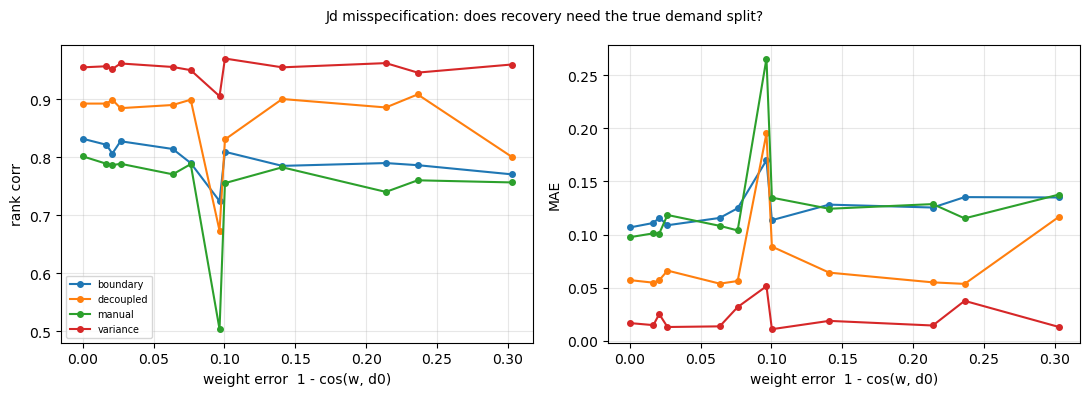

C:\Users\arthu\AppData\Local\Temp\ipykernel_10772\155686351.py:133: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,slope_rank_corr,sigma_min
placement,,
boundary,-0.161,0.131
decoupled,-0.128,0.117
manual,-0.116,0.099
variance,0.007,0.335


A flat slope means the district Jacobian is dominated by BETWEEN-district routing, not the within-district split -- which is the result that makes this deployable. A steep slope means §13's 0.955 is an oracle number.


In [22]:
# =====================================================================
# 13c. Jd MISSPECIFICATION — how much does recovery depend on knowing
#      the within-district demand split?  `node_weights=d0` is the
#      oracle: the same proportional split that generates the data.
#      A client will not have it.
# =====================================================================
import networkx as nx
from scipy import stats as sps
import pathlib

N_WORLDS   = 20
RNG_SEEDS  = [0, 1, 2]
LOGN_SIGMA = [0.25, 0.50, 1.00]

d0_pos = d0.clip(lower=0.0)

def w_true():                        # oracle
    return d0_pos.copy()

def w_uniform():
    return pd.Series(1.0, index=d0.index)

def w_drift(wn, seed_node, hops=3, boost=20.0):
    """Post-drift concentration: BFS ball around drift_seed_node carries
    most of the district's demand move. Violates the proportional-split
    assumption district_jacobian() is built on."""
    G = wn.to_graph().to_undirected()
    w = d0_pos.copy()
    if seed_node in G:
        ball = nx.single_source_shortest_path_length(G, seed_node, cutoff=hops)
        for n, h in ball.items():
            if n in w.index:
                w[n] *= boost / (1.0 + h)
    return w

def w_lognormal(sigma, seed):
    rng = np.random.default_rng(seed)
    return d0_pos * np.exp(rng.normal(0, sigma, len(d0_pos)))

def w_err(w, districts):
    """Mean over districts of 1 - cos(w_used, w_true), restricted to each
    district's own nodes -- only the WITHIN-district split matters, the
    between-district scale cancels in a correlation."""
    e = []
    for d, nodes in districts["districts"].items():
        nn = [n for n in nodes if n in w.index and n in d0_pos.index]
        if len(nn) < 2:
            continue
        a, b = w.reindex(nn).fillna(0).to_numpy(), d0_pos.reindex(nn).to_numpy()
        na, nb = np.linalg.norm(a), np.linalg.norm(b)
        if na and nb:
            e.append(1.0 - float(a @ b) / (na * nb))
    return float(np.mean(e)) if e else np.nan

idx = P.discover_worlds(PROJ).query("usable and variant=='baseline'").head(N_WORLDS)
rows = []
for k, (_, w) in enumerate(idx.iterrows(), 1):
    a  = P.load_world(w["dir"])
    dm = pd.read_parquet(pathlib.Path(w["dir"])
                         / "clone/data/02_intermediate/demand_series.parquet")
    agg = pd.DataFrame({d: dm[[c for c in dm.columns
                               if c != "month" and n2d.get(c) == d]].sum(axis=1)
                        for d in ds})
    truth = {(x, y): float(np.corrcoef(agg[x], agg[y])[0, 1])
             for i, x in enumerate(ds) for y in ds[i + 1:]}

    seed_node = w.get("drift_seed_node")
    variants = {"true(d0)": w_true(), "uniform": w_uniform()}
    if isinstance(seed_node, str) and seed_node:
        variants["drift_concentrated"] = w_drift(a["wn"], seed_node)
    for sg in LOGN_SIGMA:
        for sd in RNG_SEEDS:
            variants[f"logn_s{sg:g}_{sd}"] = w_lognormal(sg, sd)

    for name, pl in PLACES.items():
        sens = [e for d in ds for e in pl[d]["flow"]]
        s = P.build_series(a["pressures"], a["flows"],
                           {d: {"pressure": [], "flow": pl[d]["flow"]} for d in ds})
        s = s[s["kind"] == "flow"]
        Y0 = s.pivot(index="step", columns="sensor", values="observed")
        Y0 = Y0.rename(columns={c: pipe_of(c, JD[name].index) for c in Y0.columns})
        Y0 = Y0[[c for c in JD[name].index if c in Y0.columns]]
        if Y0.shape[1] < len(ds):
            continue

        for vname, wv in variants.items():
            Jd = S.district_jacobian(sweep, DISTRICTS, sens,
                                     delta=DELTAS[1], node_weights=wv)
            q  = S.unmixing_quality(Jd)
            Dh = S.unmix_demands(Y0, Jd)
            est = {(x, y): float(np.corrcoef(Dh[x], Dh[y])[0, 1])
                   for i, x in enumerate(ds) for y in ds[i + 1:]}
            rows.append(dict(
                sim_hash=w["sim_hash"], cmap=w["consumption_map"],
                placement=name, weights=vname,
                family=vname.split("_")[0] if vname.startswith("logn")
                       else vname,
                w_err=w_err(wv, DISTRICTS),
                sigma_min=q["sigma_min"], cond=q["cond"],
                rank_corr=sps.spearmanr([est[t] for t in truth],
                                        [truth[t] for t in truth]).statistic,
                mae=float(np.mean([abs(est[t] - truth[t]) for t in truth]))))
    if k % 5 == 0:
        print(f"  {k}/{len(idx)}")

W = pd.DataFrame(rows)

# ---- headline table: degradation vs the oracle -----------------------
agg_w = (W.groupby(["placement", "weights"])
         [["w_err", "sigma_min", "rank_corr", "mae"]].mean())
base = agg_w.xs("true(d0)", level="weights")["rank_corr"]
agg_w["drop_vs_oracle"] = (agg_w["rank_corr"]
                           - agg_w.index.get_level_values("placement").map(base))
display(agg_w.round(3))

# ---- the curve: recovery as a function of weight error ---------------
curve = (W.groupby(["placement", "weights"])[["w_err", "rank_corr", "mae"]]
         .mean().reset_index())
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for name, g in curve.groupby("placement"):
    g = g.sort_values("w_err")
    ax[0].plot(g.w_err, g.rank_corr, "o-", ms=4, label=name)
    ax[1].plot(g.w_err, g.mae, "o-", ms=4, label=name)
ax[0].set_xlabel("weight error  1 - cos(w, d0)"); ax[0].set_ylabel("rank corr")
ax[1].set_xlabel("weight error  1 - cos(w, d0)"); ax[1].set_ylabel("MAE")
ax[0].legend(fontsize=7); ax[0].grid(alpha=.3); ax[1].grid(alpha=.3)
fig.suptitle("Jd misspecification: does recovery need the true demand split?",
             fontsize=10)
fig.tight_layout(); plt.show()

# ---- is the sensitivity itself placement-dependent? ------------------
sens_tbl = (curve.groupby("placement")
            .apply(lambda g: pd.Series({
                "slope_rank_corr": np.polyfit(g.w_err, g.rank_corr, 1)[0],
                "sigma_min": float(W[W.placement == g.name].sigma_min.mean())}))
            .sort_values("slope_rank_corr"))
display(sens_tbl.round(3))
print("A flat slope means the district Jacobian is dominated by BETWEEN-"
      "district routing, not the within-district split -- which is the "
      "result that makes this deployable. A steep slope means §13's 0.955 "
      "is an oracle number.")